# 04 — Generate the Model B training images

This notebook loads a completed SRGAN checkpoint and generates 128×128 training images **only** for records in `data/splits/train.csv`. The reusable generation module provides checkpoint validation, deterministic names, checkpoint provenance, atomic writes, and safe resumption. No test record is read here.

## 1. Open the local repository

Start Jupyter from the local repository and select the project virtual environment as the notebook kernel. This cell automatically locates the repository root.

In [1]:
import sys
from pathlib import Path

start_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (start_directory, *start_directory.parents)
        if (candidate / 'pyproject.toml').is_file()
        and (candidate / 'src' / 'applied_ai_midterm').is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    codex_workspace = Path.home() / 'Documents' / 'Codex'
    if codex_workspace.is_dir():
        PROJECT_ROOT = next(
            (
                config_file.parent
                for config_file in codex_workspace.rglob('pyproject.toml')
                if config_file.parent.name == 'MLawson-Applied-AI-Midterm'
                and (config_file.parent / 'src' / 'applied_ai_midterm').is_dir()
            ),
            None,
        )
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Open this notebook from inside the MLawson-Applied-AI-Midterm repository.'
    )
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Local project root: {PROJECT_ROOT}')
print(f'Python kernel: {sys.executable}')

Local project root: <PROJECT_ROOT>
Python kernel: <PROJECT_ROOT>/.venv/bin/python


## 2. Configure local data and the completed checkpoint

The raw layout must be either `data/raw/<class>/...` or `data/raw/train/<class>/...`. Generated images, their manifest, and checkpoint provenance are saved inside the local repository's ignored `data/generated/` directory.

In [2]:
RAW_DIRECTORY = PROJECT_ROOT / 'data' / 'raw'
TRAIN_MANIFEST = PROJECT_ROOT / 'data' / 'splits' / 'train.csv'
CHECKPOINT_DIRECTORY = PROJECT_ROOT / 'artifacts' / 'checkpoints' / 'srgan'
CHECKPOINT = CHECKPOINT_DIRECTORY / 'srgan_epoch_0150.pt'
OUTPUT_DIRECTORY = PROJECT_ROOT / 'data' / 'generated' / 'model_b_train'
OUTPUT_MANIFEST = PROJECT_ROOT / 'data' / 'generated' / 'model_b_train.csv'

print(f'Raw images: {RAW_DIRECTORY}')
print(f'Train manifest: {TRAIN_MANIFEST}')
print(f'Generator checkpoint: {CHECKPOINT}')
print(f'Local output: {OUTPUT_DIRECTORY}')
if not RAW_DIRECTORY.is_dir():
    raise FileNotFoundError(
        f'Raw dataset missing at {RAW_DIRECTORY}. Run notebook 01 setup first.'
    )
if not TRAIN_MANIFEST.is_file():
    raise FileNotFoundError(
        f'Training manifest missing at {TRAIN_MANIFEST}. Run notebook 01 first.'
    )
if not CHECKPOINT.is_file():
    raise FileNotFoundError(
        f'Completed SRGAN checkpoint missing at {CHECKPOINT}. '
        'Run notebook 03 through epoch 150, then Run all again.'
    )

Raw images: <PROJECT_ROOT>/data/raw
Train manifest: <PROJECT_ROOT>/data/splits/train.csv
Generator checkpoint: <PROJECT_ROOT>/artifacts/checkpoints/srgan/srgan_epoch_0150.pt
Local output: <PROJECT_ROOT>/data/generated/model_b_train


## 3. Select the accelerator and validate the generation plan

The dry run validates the checkpoint, configuration, class mapping, manifest, and source paths without writing anything. It also reports how many already-valid files would be skipped after a disconnect.

In [3]:
from applied_ai_midterm.generation import generate_model_b_dataset
from applied_ai_midterm.training import select_device

device = select_device()
print(f'Selected device: {device}')
if device.type == 'cpu':
    print('Warning: generation on CPU may take a while.')

dry_run = generate_model_b_dataset(
    CHECKPOINT,
    raw_directory=RAW_DIRECTORY,
    train_manifest_path=TRAIN_MANIFEST,
    output_directory=OUTPUT_DIRECTORY,
    output_manifest_path=OUTPUT_MANIFEST,
    device=device,
    batch_size=16,
    num_workers=2,
    dry_run=True,
)
dry_run

Selected device: mps


GenerationSummary(total=17451, generated=17451, skipped=0, dry_run=True, output_directory=PosixPath('<PROJECT_ROOT>/data/generated/model_b_train'), manifest_path=PosixPath('<PROJECT_ROOT>/data/generated/model_b_train.csv'), checkpoint_identifier='5b844f206357906aaafa53ab8b148a683dd4e49817188bb0a02bc2cb1e7b13a8')

## 4. Generate or safely resume

Rerun **Run all** after an interruption. Completed readable files made by this exact checkpoint are not regenerated. If the checkpoint changes, use a new output directory; the generator refuses to overwrite a different run.

In [4]:
summary = generate_model_b_dataset(
    CHECKPOINT,
    raw_directory=RAW_DIRECTORY,
    train_manifest_path=TRAIN_MANIFEST,
    output_directory=OUTPUT_DIRECTORY,
    output_manifest_path=OUTPUT_MANIFEST,
    device=device,
    batch_size=16,
    num_workers=2,
)
print(summary)

Generating Model B images:   0%|          | 0/1091 [00:06<?, ?it/s]

GenerationSummary(total=17451, generated=17451, skipped=0, dry_run=False, output_directory=PosixPath('<PROJECT_ROOT>/data/generated/model_b_train'), manifest_path=PosixPath('<PROJECT_ROOT>/data/generated/model_b_train.csv'), checkpoint_identifier='5b844f206357906aaafa53ab8b148a683dd4e49817188bb0a02bc2cb1e7b13a8')


## 5. Inspect the full image path

Each row shows the original source, the actual 32×32 generator input, its bicubic 128×128 enlargement, the saved generator result, and the aligned real 128×128 target.

Checkpoint SHA-256: 5b844f206357906aaafa53ab8b148a683dd4e49817188bb0a02bc2cb1e7b13a8


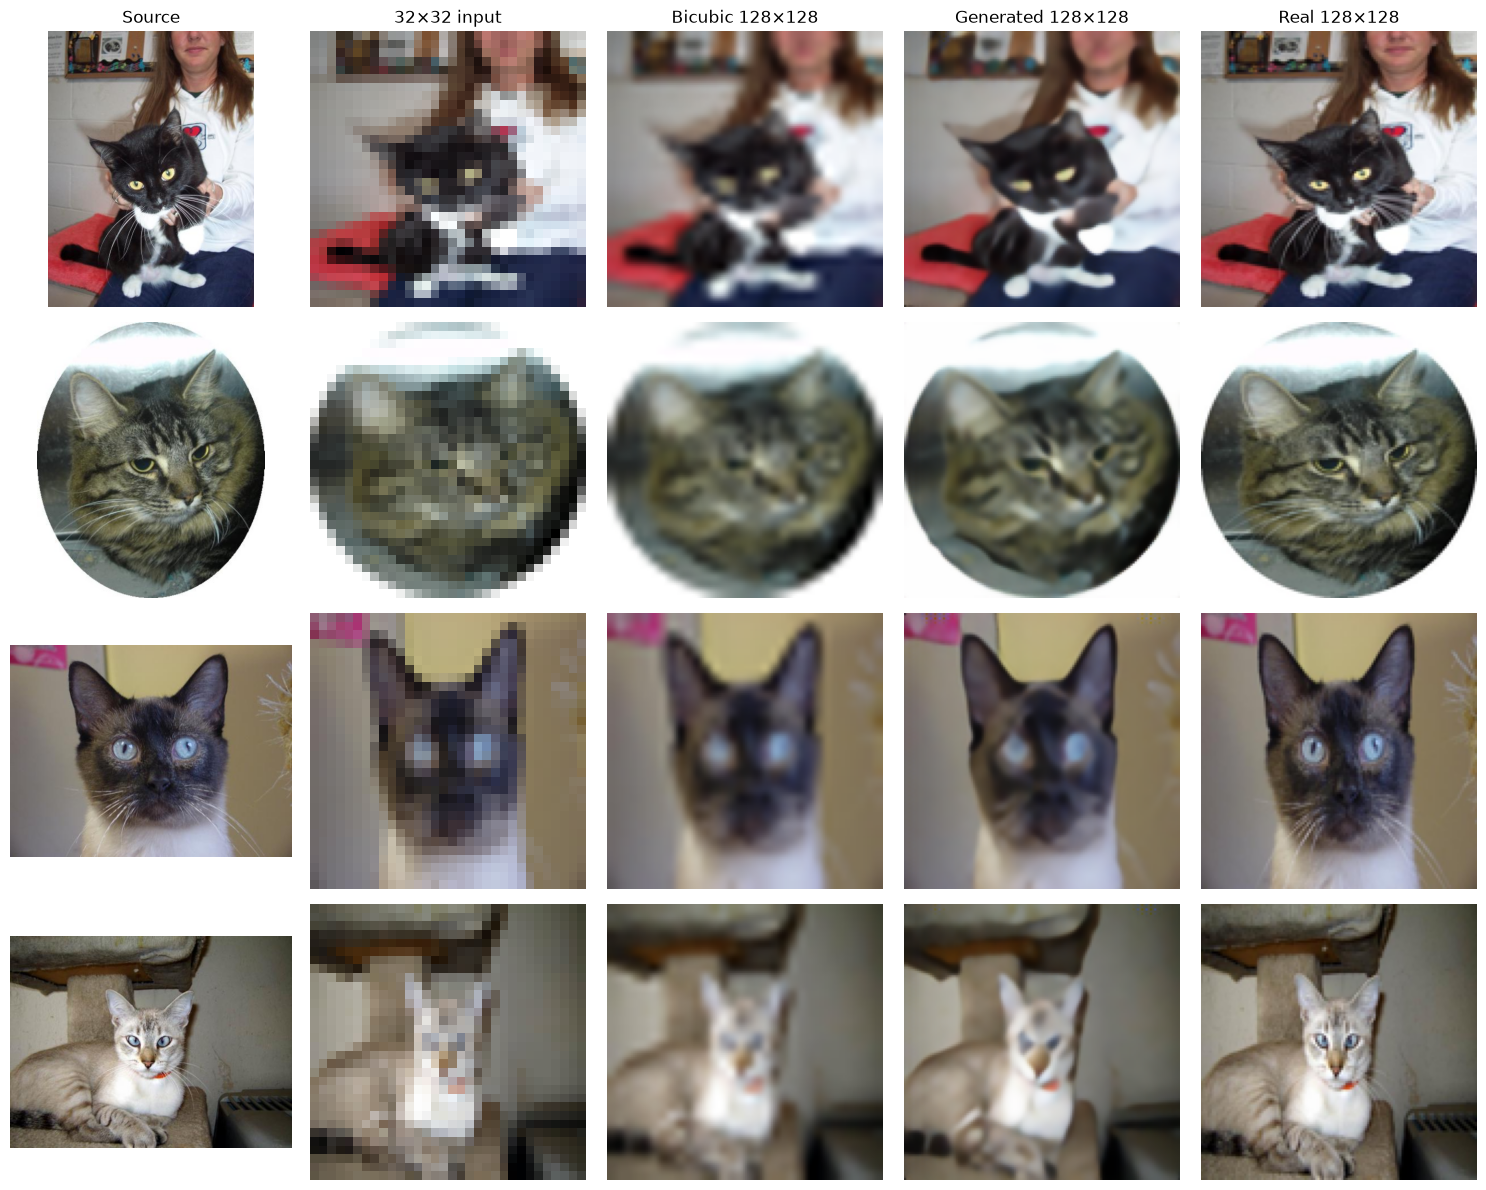

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF

from applied_ai_midterm.generation import load_generator_checkpoint
from applied_ai_midterm.transforms import SRGANPairTransform, denormalize_srgan

generator, checkpoint_info = load_generator_checkpoint(CHECKPOINT, device=device)
pairs = SRGANPairTransform(32, 128, training=False)
generated_manifest = pd.read_csv(OUTPUT_MANIFEST)
examples = generated_manifest.head(4)
figure, axes = plt.subplots(
    len(examples), 5, figsize=(15, 3 * len(examples)), squeeze=False
)
for row_number, row in enumerate(examples.itertuples(index=False)):
    with Image.open(RAW_DIRECTORY / row.source_filepath) as opened:
        source = opened.convert('RGB')
    low, real = pairs(source)
    low_display = TF.to_pil_image(denormalize_srgan(low))
    bicubic = TF.resize(
        low_display,
        [128, 128],
        interpolation=InterpolationMode.BICUBIC,
        antialias=True,
    )
    with Image.open(OUTPUT_MANIFEST.parent / row.filepath) as opened:
        generated = opened.convert('RGB')
    real_display = TF.to_pil_image(denormalize_srgan(real))
    displays = [source, low_display, bicubic, generated, real_display]
    pairs_to_plot = zip(axes[row_number], displays, strict=True)
    for column, (axis, image) in enumerate(pairs_to_plot):
        axis.imshow(image)
        axis.axis('off')
        if row_number == 0:
            titles = [
                'Source',
                '32×32 input',
                'Bicubic 128×128',
                'Generated 128×128',
                'Real 128×128',
            ]
            axis.set_title(titles[column])
plt.tight_layout()
print(f'Checkpoint SHA-256: {checkpoint_info.identifier}')